In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup
from tqdm.notebook import tqdm
import scipy.signal as sp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [4]:
patch_fs_c21 = 50023.897143583



In [5]:
patch_c21 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c21patch_filt.npy'
#get cell number 
cell_num = 'c21'


#get patch data 
patch_filt_c21 = np.load(patch_c21)
patch_c21_one_ms = float(patch_fs_c21  / 1000)
patch_times_c21 = np.arange(0, np.shape(patch_filt_c21 )[0]) / patch_c21_one_ms # in ms instead of sec


patch_channel = -patch_filt_c21


# IAP to inferred EAP

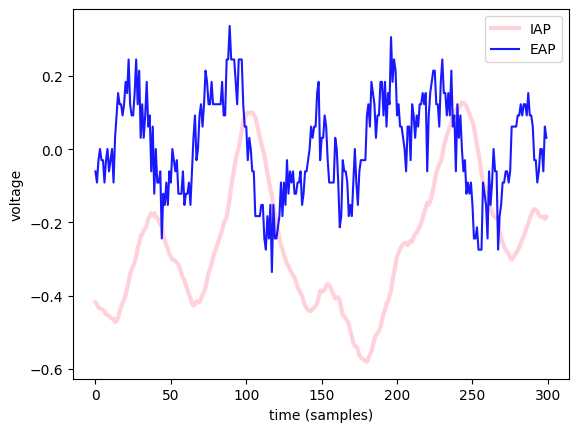

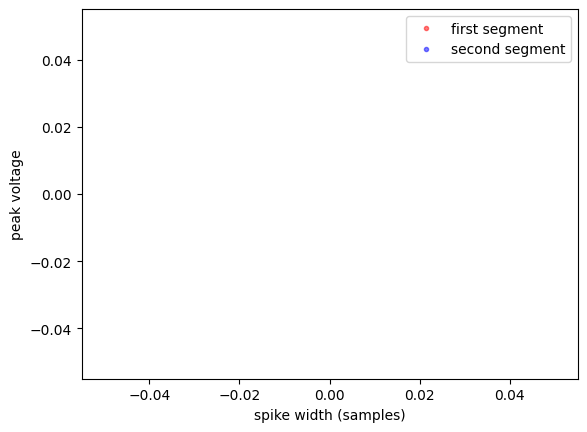

In [6]:


patch_fs = patch_fs_c21

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 10 # this is arbitrary, just to scale it better to the iap

first_segment = iap2eap[:3000000]
last_segment = iap2eap[51000000:54000000]


# show that the pseudo-eap works
plt.plot(patch_filt[21900:22200], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[21900:22200], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()




# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 200, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 200, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

### Check how the inferred EAPs compare to the actual EAPs

In [122]:
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c21npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = float(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109

In [123]:
# open and load the data
npx_filt = np.load(npx_path)

npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

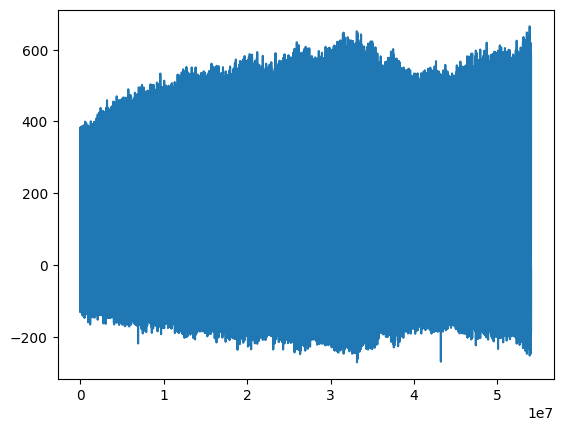

In [124]:
plt.plot(iap2eap)

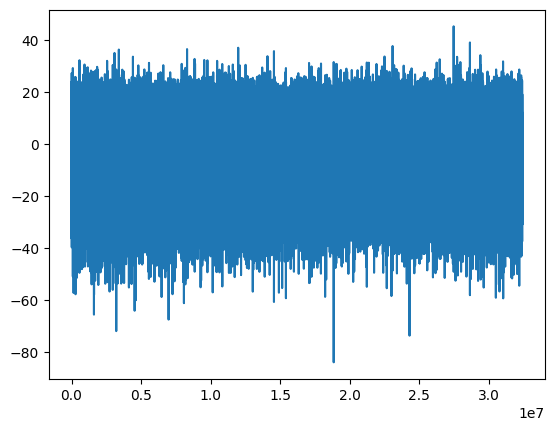

In [125]:
plt.plot(npx_filt)

In [126]:
#Run spikeparam on real EAPs 
sp_ex = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1746 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


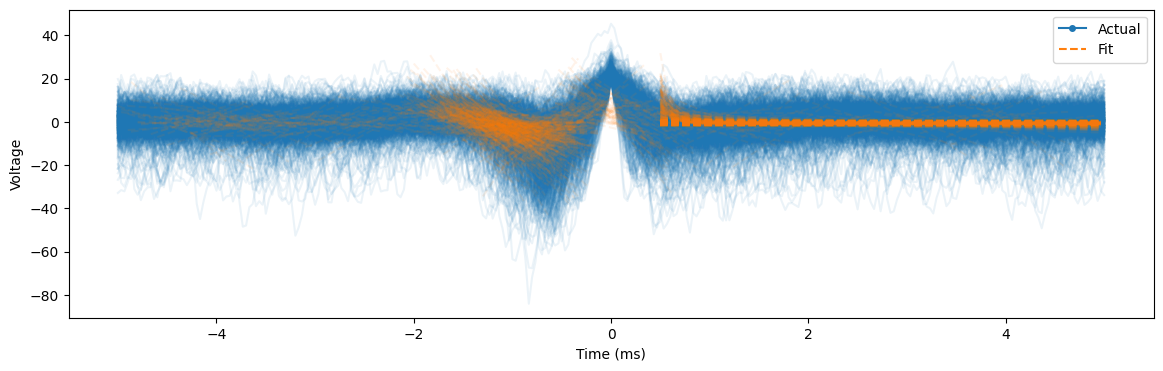

In [127]:
sp_ex.plot()

In [153]:
#clean detected EAP spikes 
df_features = sp_ex.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [154]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,original_index
0,0.078107,13.266667,-4.383741,27.339920,0.400000,8.461518,0.000058,-1.320736,300.600000,NaN,NaN,0
1,-21.831190,0.833333,-26.761189,24.145146,0.900000,8.756443,0.003411,-99.999999,935.066667,0.342498,0.006908,1
2,0.926717,12.200000,0.002766,23.952634,0.166667,15.230298,0.005537,-99.989587,1459.066667,NaN,NaN,2
3,0.134612,6.300000,-6.306877,29.265961,0.400000,7.607221,8.666148,-0.804461,137.333333,NaN,NaN,3
4,3.303903,0.266667,2.240679,21.435123,0.200000,9.633505,9.999983,0.506074,848.466667,0.113111,0.073496,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1741,-1.884371,10.466667,-7.425491,26.450478,0.533333,5.153338,0.000005,-0.276578,1042.733333,NaN,NaN,1741
1742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.700000,NaN,NaN,1742
1743,-18.579427,1.066667,-37.364995,20.866838,1.666667,10.928652,0.000005,-0.783132,990.333333,0.261565,0.029127,1743
1744,0.440013,9.266667,3.469463,24.505761,0.333333,4.388314,0.000485,-1.424933,113.200000,NaN,NaN,1744


(array([157.,  78.,  81.,  72.,  71.,  61.,  77.,  44.,  26.,  13.]),
 array([1.77307616e-05, 9.40545794e-02, 1.88091428e-01, 2.82128277e-01,
        3.76165125e-01, 4.70201974e-01, 5.64238823e-01, 6.58275671e-01,
        7.52312520e-01, 8.46349369e-01, 9.40386217e-01]),
 <BarContainer object of 10 artists>)

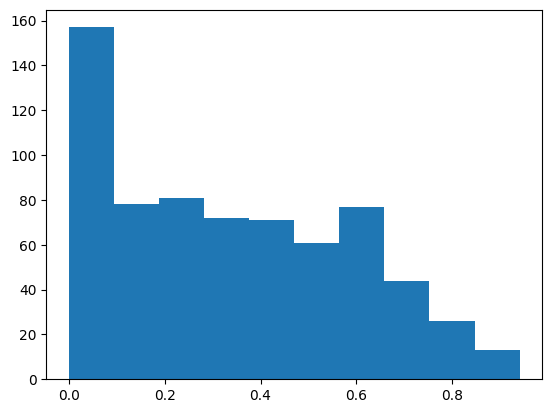

In [155]:
plt.hist(df_features['r_squared_ramp'])

(array([387., 139., 106.,  41.,  22.,  11.,  10.,   3.,   4.,   4.]),
 array([2.49319503e-34, 2.70888802e-02, 5.41777604e-02, 8.12666406e-02,
        1.08355521e-01, 1.35444401e-01, 1.62533281e-01, 1.89622161e-01,
        2.16711042e-01, 2.43799922e-01, 2.70888802e-01]),
 <BarContainer object of 10 artists>)

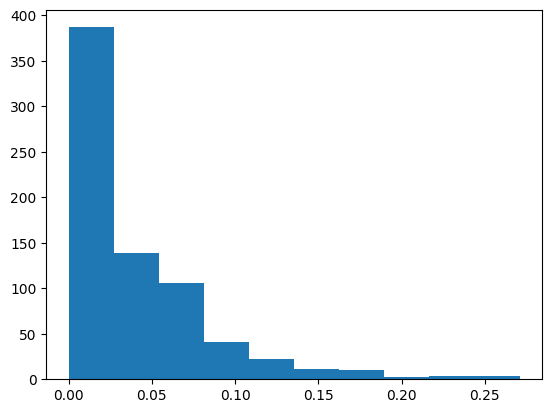

In [156]:
plt.hist(df_features['r_squared_exp'])

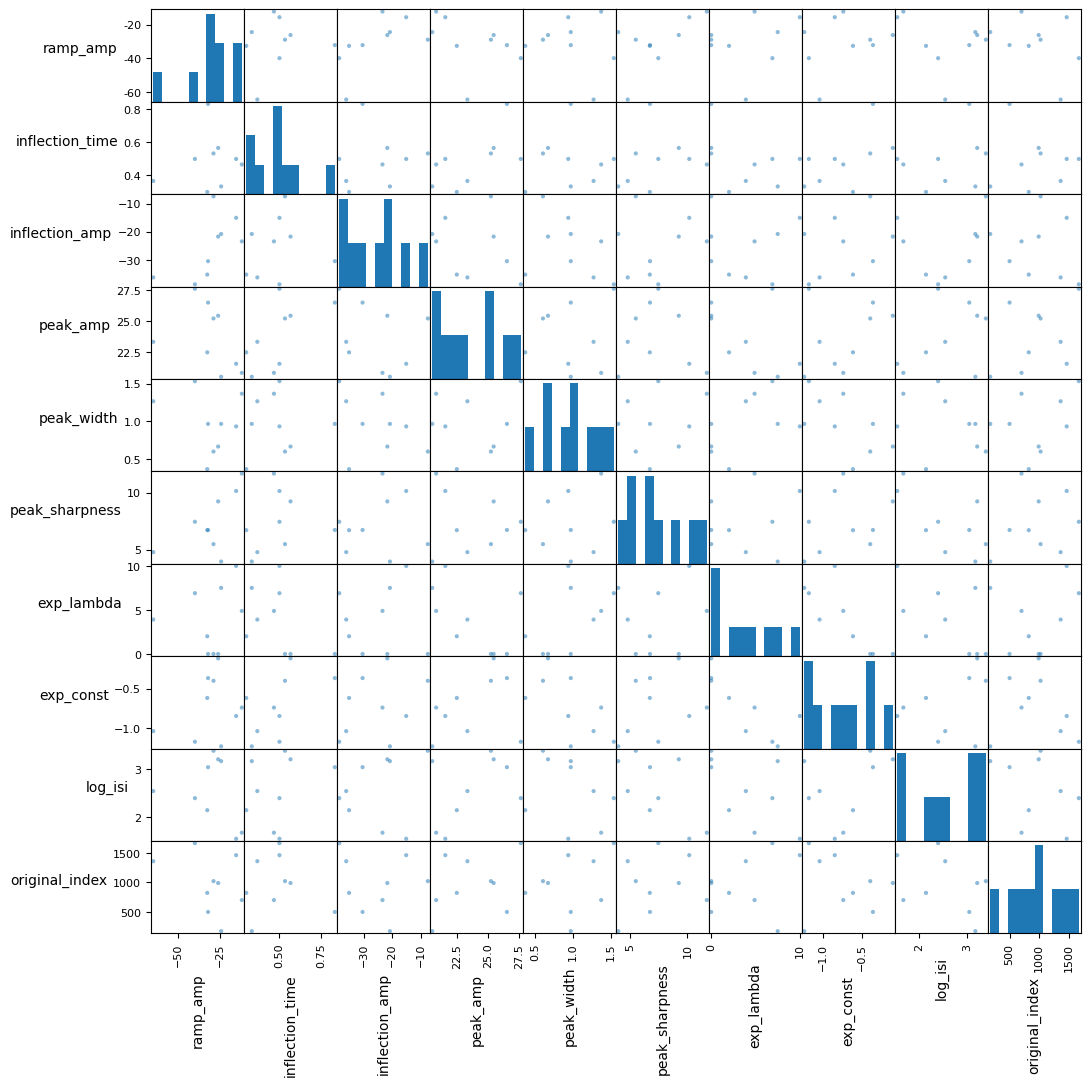

In [157]:
# Ensure inflection times are between 0 and 2 ms
#df_features  = df_features .loc[df_features['inflection_time'] > 0.]
#df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .2]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .01]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

In [128]:
#Downsample inferred EAPs to match real EAP sampling rate
iap2eap = sp.resample(iap2eap, int((len(iap2eap)/patch_fs)*npx_fs))

In [129]:
#Rescale inferred EAPs so that it matches real EAPs 
iap2eap_scaled = iap2eap/ 1 # this is arbitrary, just to scale it better to the iap

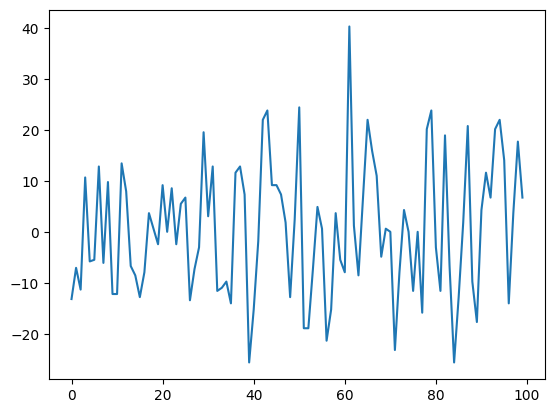

In [115]:
plt.plot(iap2eap_scaled[0:100])

In [32]:
#Run spikeparam on inferred EAPs 

sp_ex_inf = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex_inf.fit(iap2eap, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3568 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


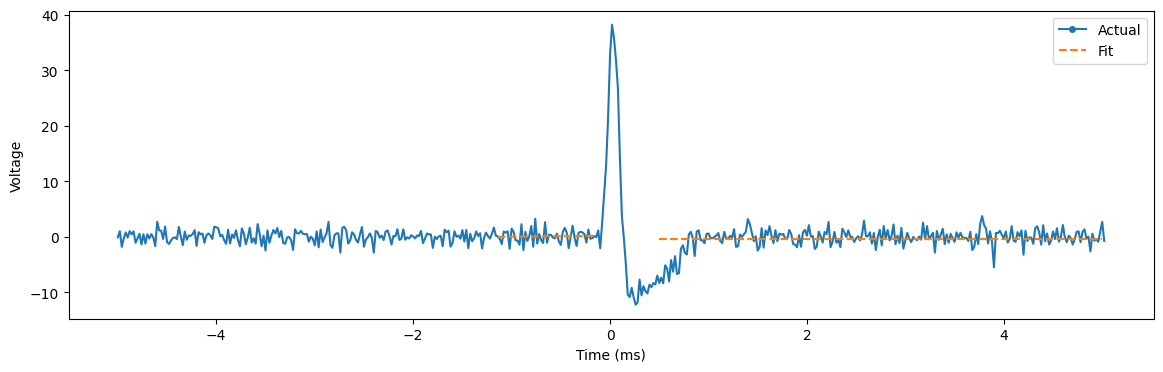

In [33]:
sp_ex_inf.plot(10
)

#### Temporally align real EAPs and inferred EAPs, only inferred ones that align with the real EAPs

In [34]:
sp_ex_inf_inds = sp_ex_inf.spike_inds
sp_ex_inds = sp_ex.spike_inds

sp_ex_inf_inds_ms = patch_times_c21[sp_ex_inf.spike_inds]
sp_ex_inds_ms = npx_times[sp_ex.spike_inds]

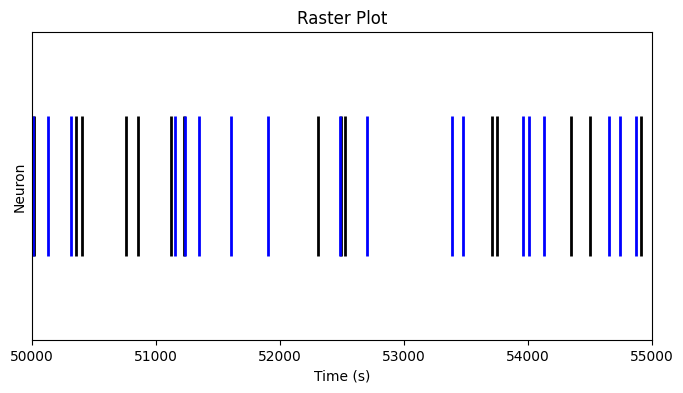

In [35]:
# Plotting the raster plot
plt.figure(figsize=(8, 4))
plt.eventplot(sp_ex_inds_ms, color='black', linewidths=2)
plt.eventplot(sp_ex_inf_inds_ms, color='blue', linewidths=2)
plt.xlabel('Time (s)')
plt.xlim(50000, 55000)
plt.ylabel('Neuron')
plt.title('Raster Plot')
plt.yticks([])  # Disable y-axis ticks as this is a raster plot
plt.show()

#### Calculate coincident and extraneous spikes between real IAPs and real EAPs

In [36]:
#Run spikeparam on IAPs 

sp = Spike(thresh_amp=400, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3968 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


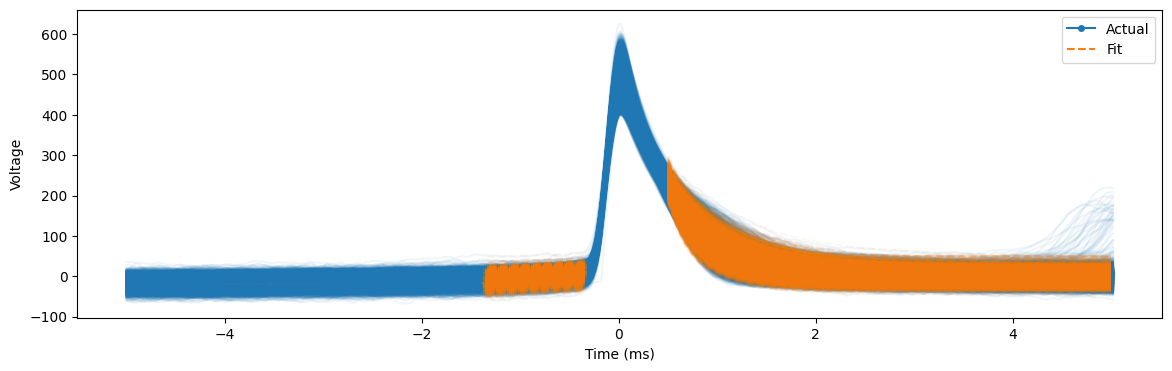

In [37]:
sp.plot()

In [38]:
sp_inds = sp.spike_inds


sp_inds_ms = patch_times_c21[sp.spike_inds]


In [95]:
coincidence_window = 0.3 # milliseconds
# Lists to store the coincident spike times
coincident_eap_spikes = []
coincident_iap_spikes = []

coincident_eap_spike_num = []
coincident_iap_spike_num = []

#Initialize counters
coincident_count = 0
non_coincident_eap_count = 0
non_coincident_iap_count = 0

# Iterate through each EAP spike time
sp_ex_counter = 0 
for eap_spike_time in sp_ex_inds_ms:
    coincident_found = False
    sp_ex_counter +=1 

    sp_counter = 0 
    # Search for coincident IAP spikes within the time window
    for iap_spike_time in sp_inds_ms:
        sp_counter +=1
        if abs(eap_spike_time - iap_spike_time) <= coincidence_window:
            coincident_count += 1
            coincident_found = True
            coincident_eap_spikes.append(eap_spike_time)  # Save coincident EAP spike time
            coincident_iap_spikes.append(iap_spike_time)  # Save coincident IAP spike time
            coincident_eap_spike_num.append(sp_ex_counter)
            coincident_iap_spike_num.append(sp_counter)
            break  # Exit the loop once a coincident spike is found
    # If no coincident IAP spike is found, increment the non-coincident EAP count
    if not coincident_found:
        non_coincident_eap_count += 1

# Calculate the number of non-coincident IAP spikes
non_coincident_iap_count = len(sp_inds_ms) - coincident_count

# Print the results
print(f"Number of coincident spikes: {coincident_count}")
print(f"Number of non-coincident EAP spikes: {non_coincident_eap_count}")
print(f"Number of non-coincident IAP spikes: {non_coincident_iap_count}")

Number of coincident spikes: 17
Number of non-coincident EAP spikes: 1729
Number of non-coincident IAP spikes: 3951


In [96]:
coincident_iap_spike_num

[34,
 169,
 187,
 393,
 410,
 411,
 852,
 879,
 894,
 1100,
 1297,
 1344,
 1427,
 1459,
 1594,
 1732,
 2903]

#### Plot coincident spikes

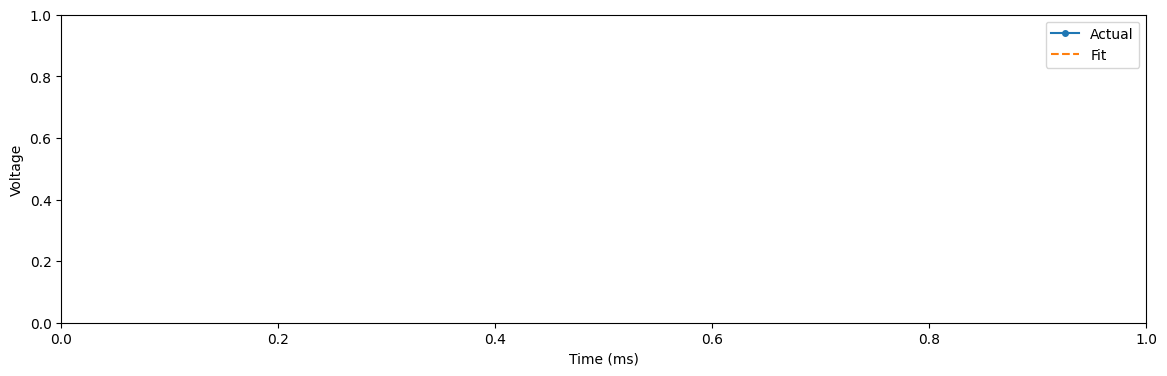

In [132]:
sp_ex.plot(329)

Plotting EAP spike at detected spike number: 54
Plotting IAP spike at detected spike number: 34
Plotting Inferred EAP spike at detected spike number: 34
Plotting EAP spike at detected spike number: 157
Plotting IAP spike at detected spike number: 169
Plotting Inferred EAP spike at detected spike number: 169
Plotting EAP spike at detected spike number: 172
Plotting IAP spike at detected spike number: 187
Plotting Inferred EAP spike at detected spike number: 187
Plotting EAP spike at detected spike number: 315
Plotting IAP spike at detected spike number: 393
Plotting Inferred EAP spike at detected spike number: 393
Plotting EAP spike at detected spike number: 328
Plotting IAP spike at detected spike number: 410
Plotting Inferred EAP spike at detected spike number: 410
Plotting EAP spike at detected spike number: 329
Plotting IAP spike at detected spike number: 411
Plotting Inferred EAP spike at detected spike number: 411
Plotting EAP spike at detected spike number: 615
Plotting IAP spike

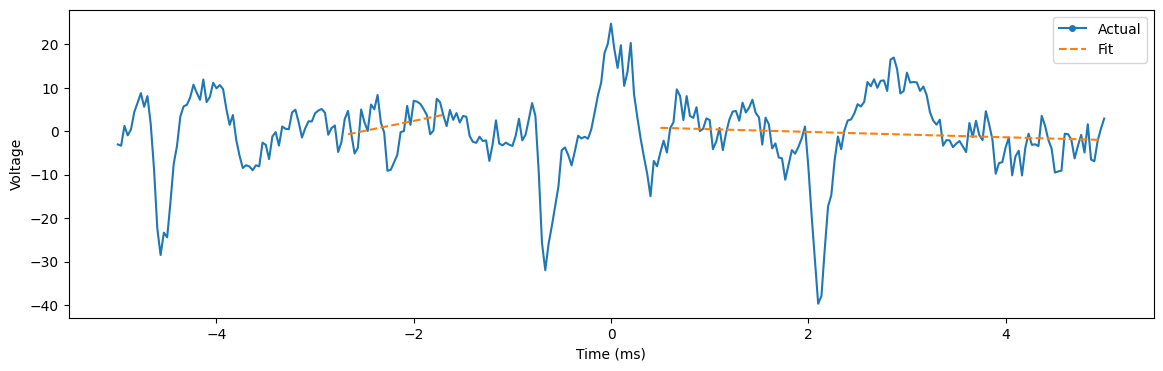

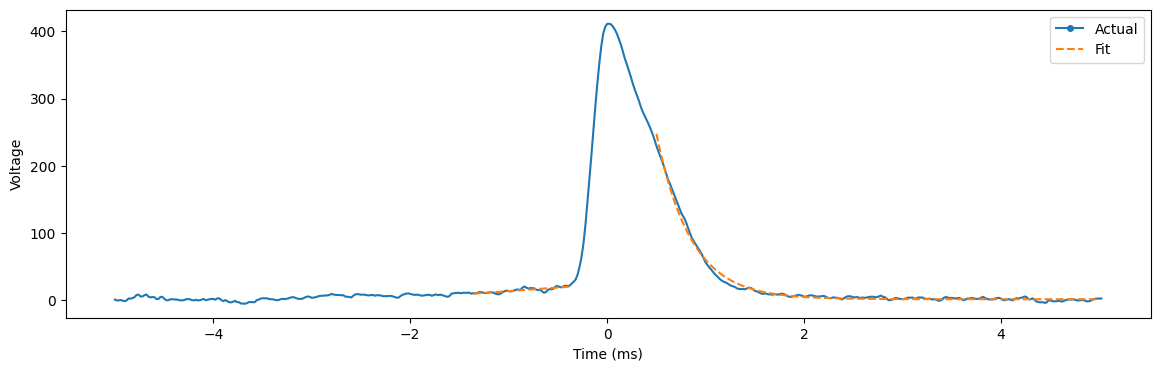

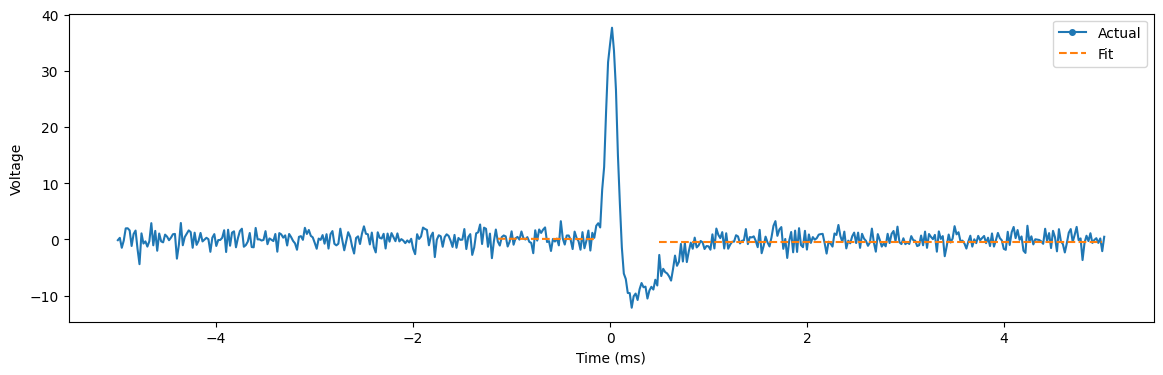

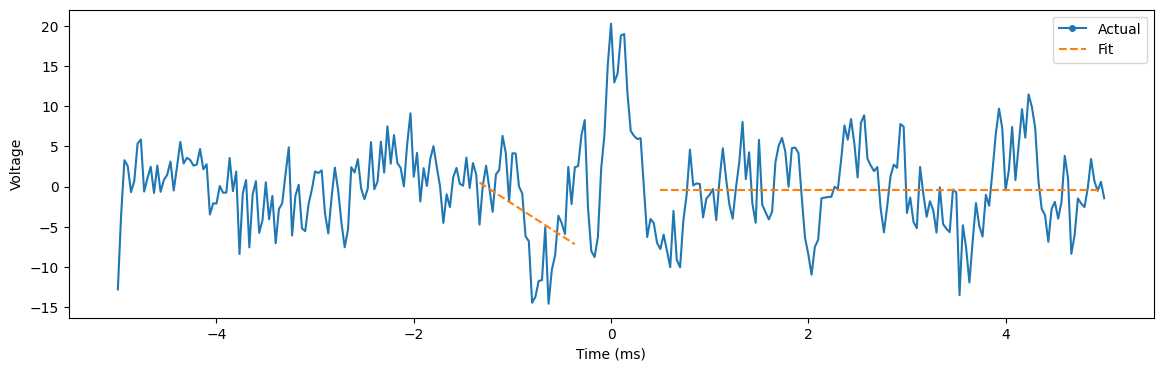

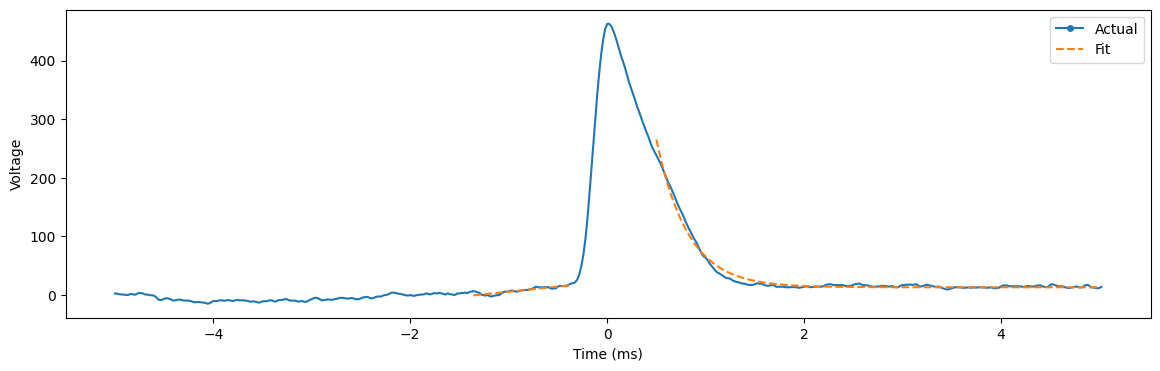

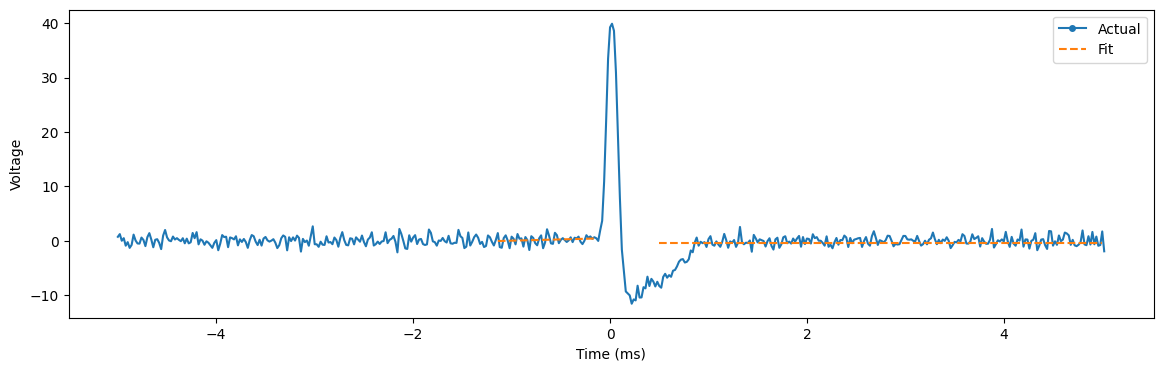

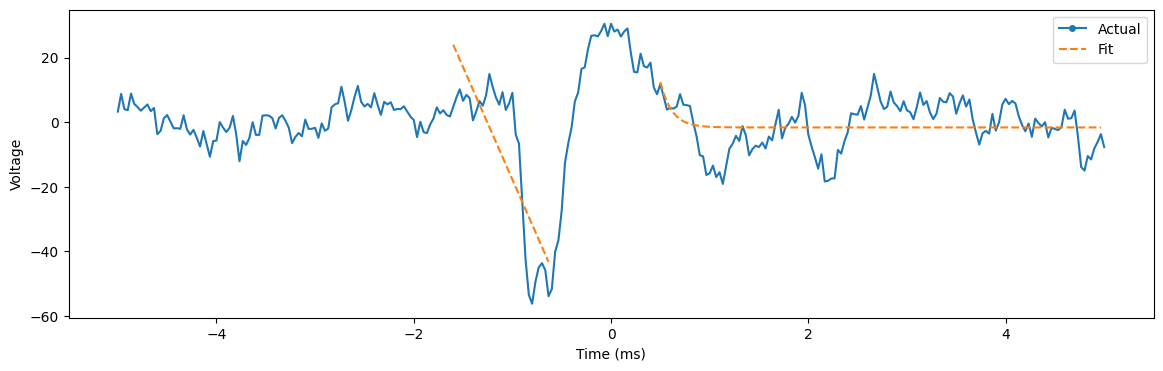

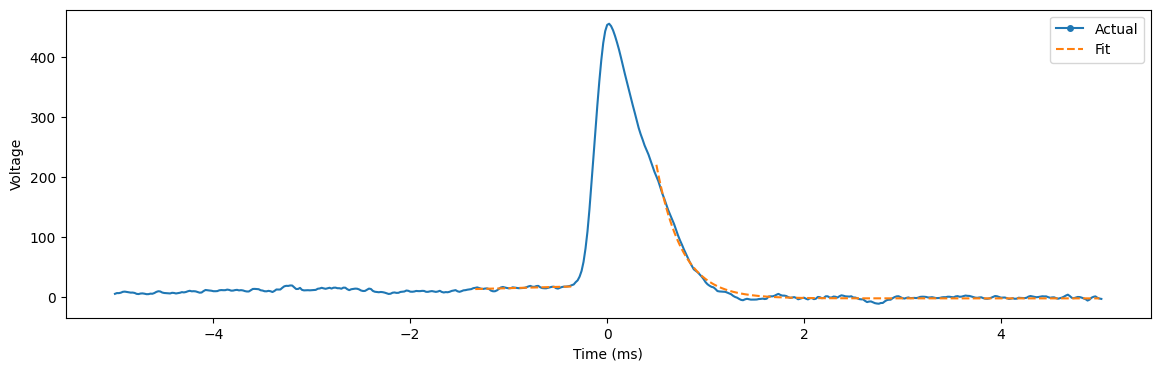

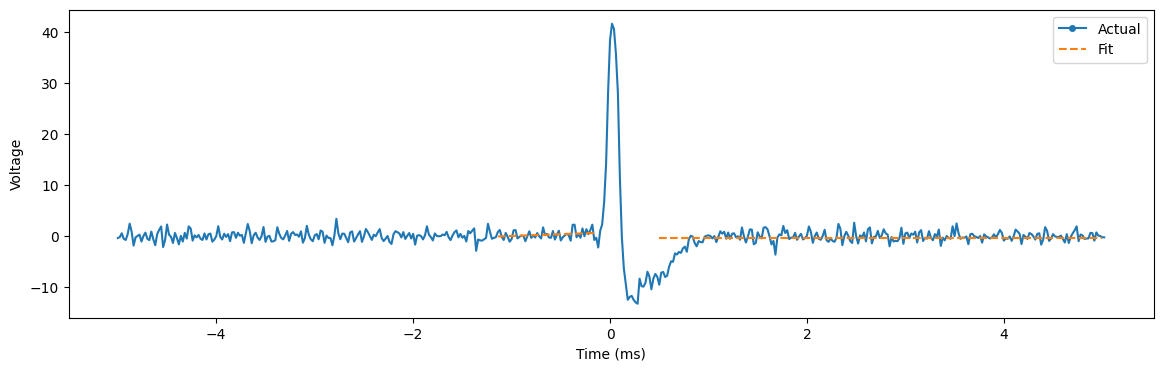

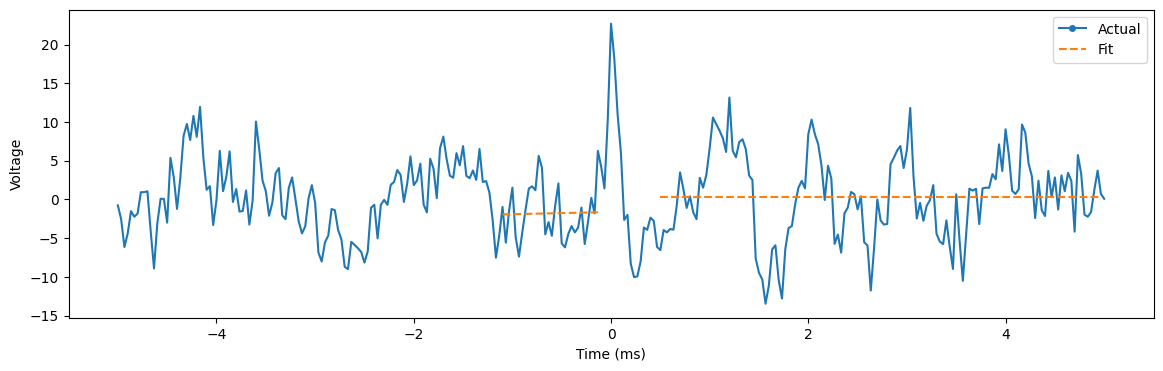

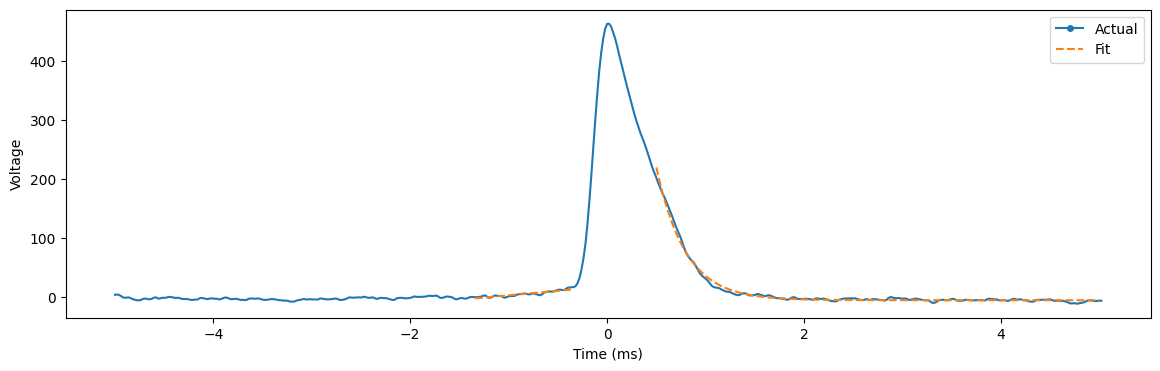

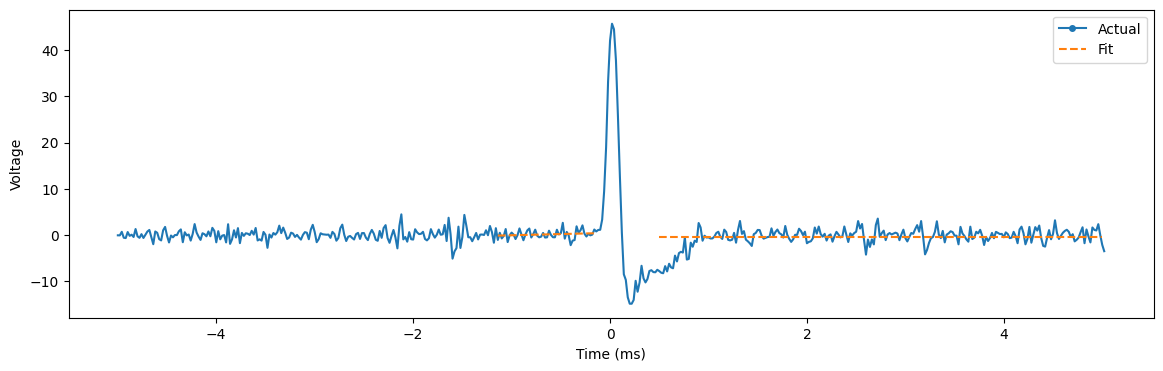

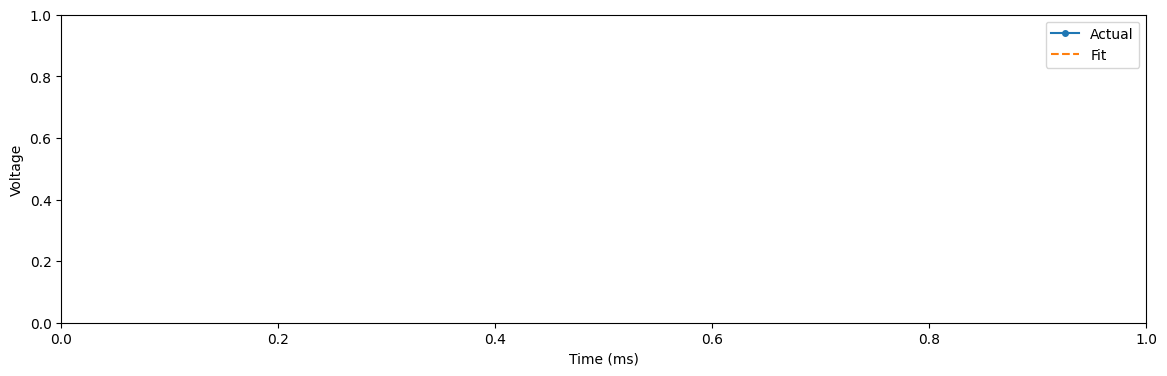

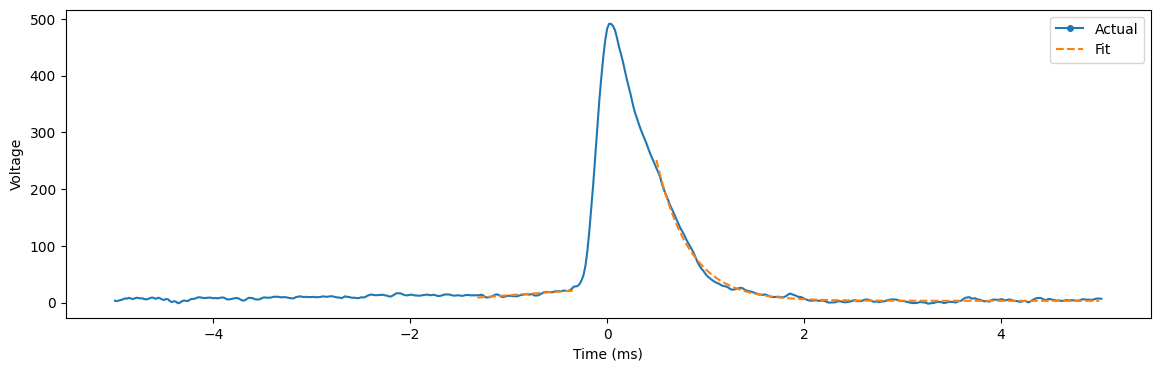

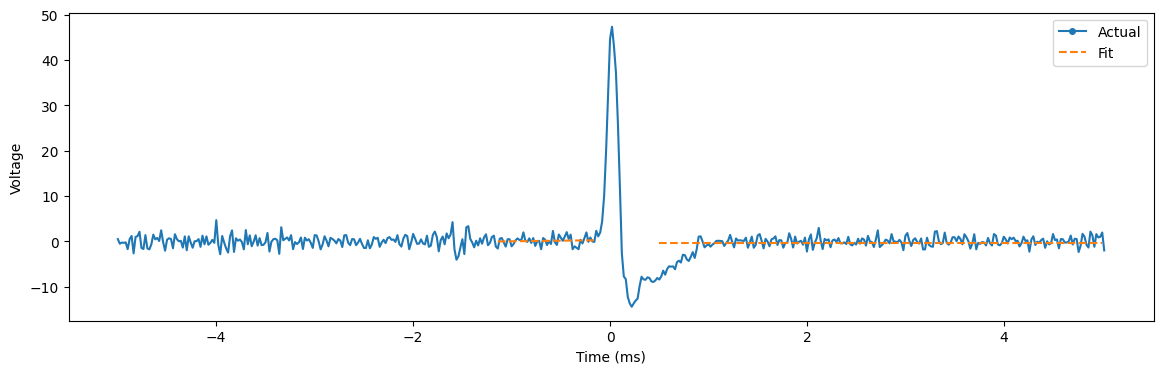

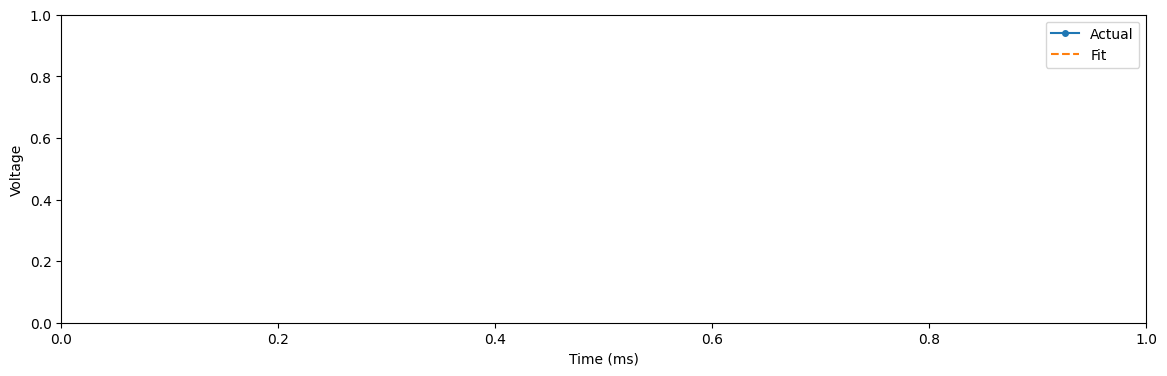

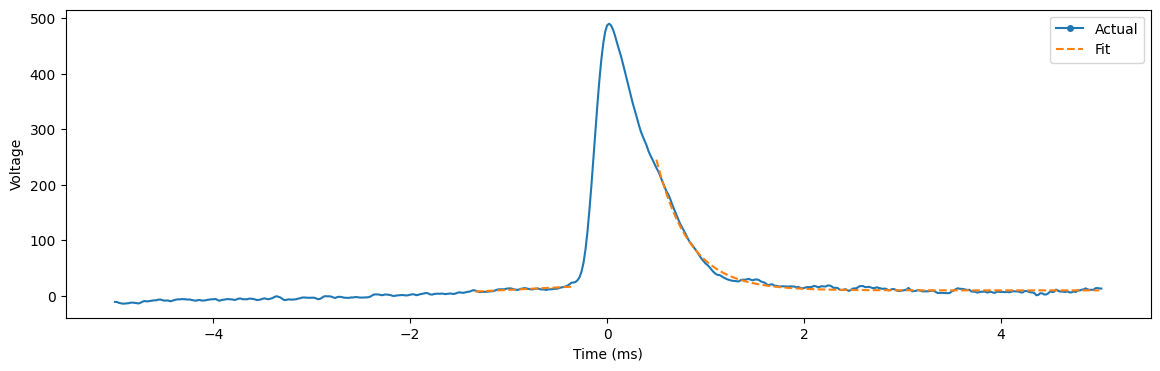

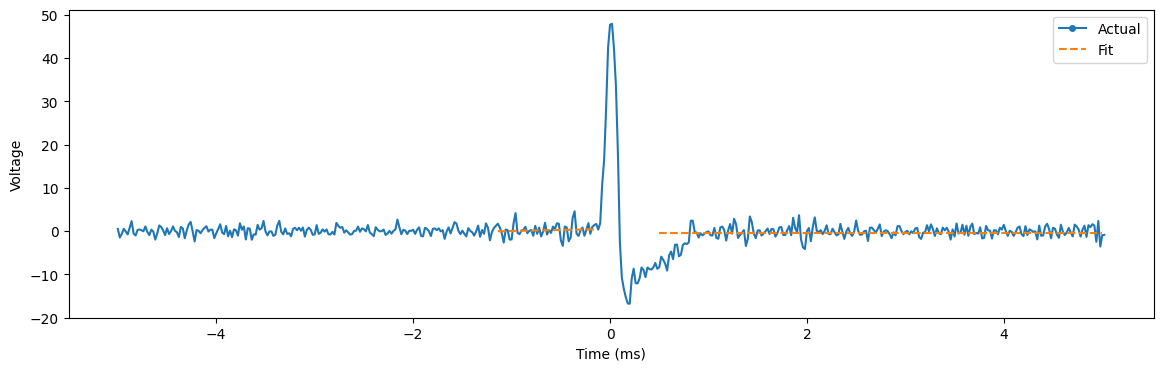

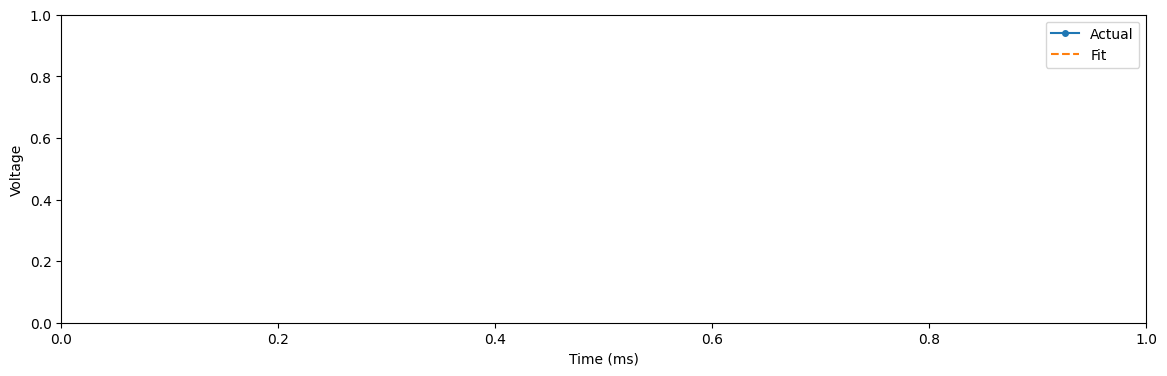

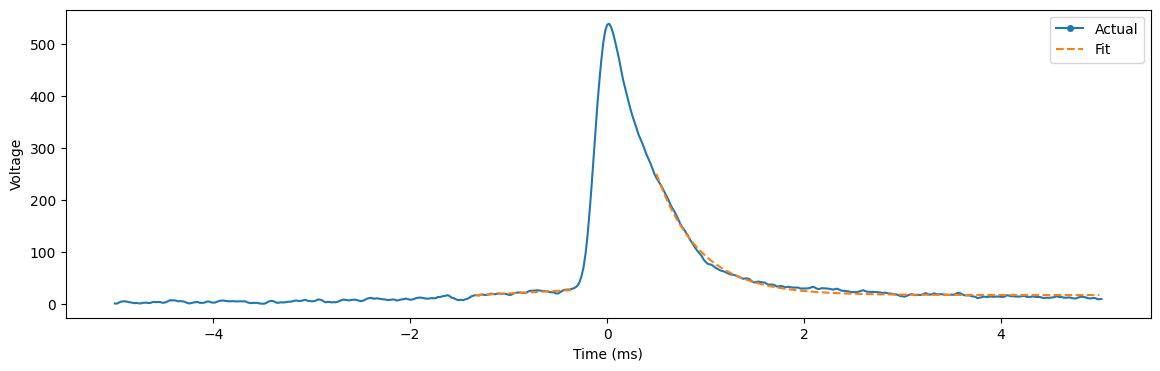

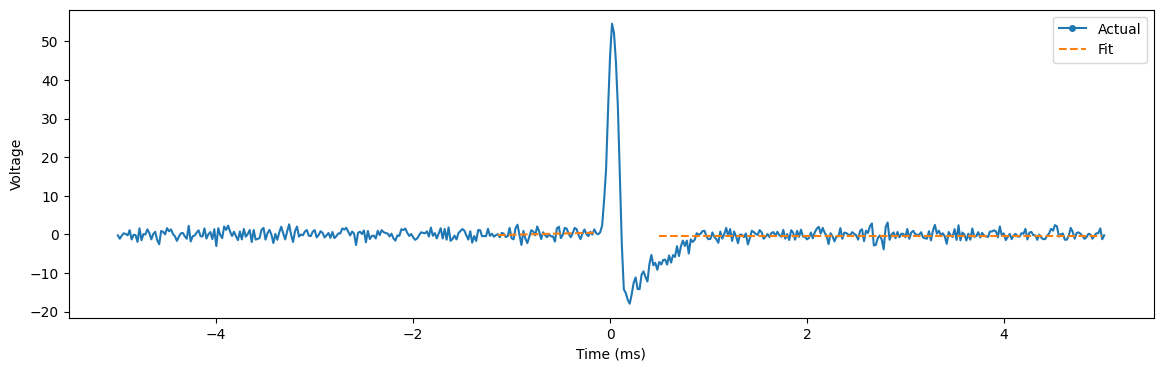

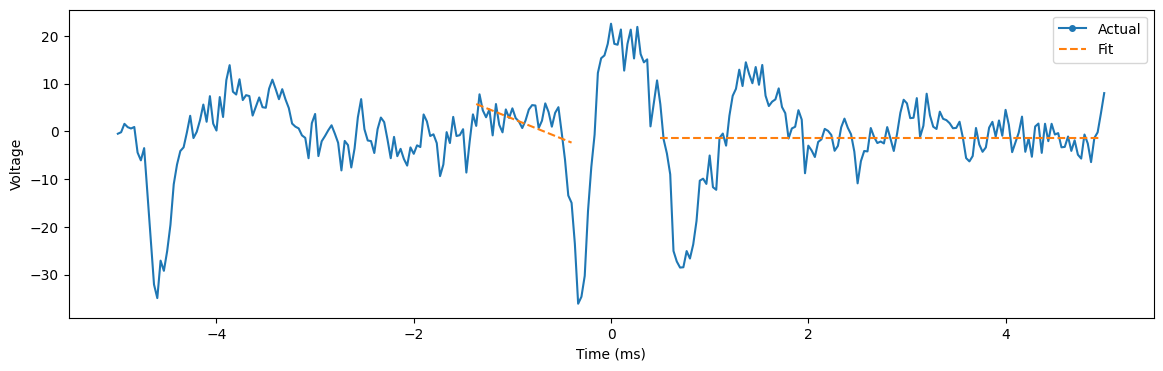

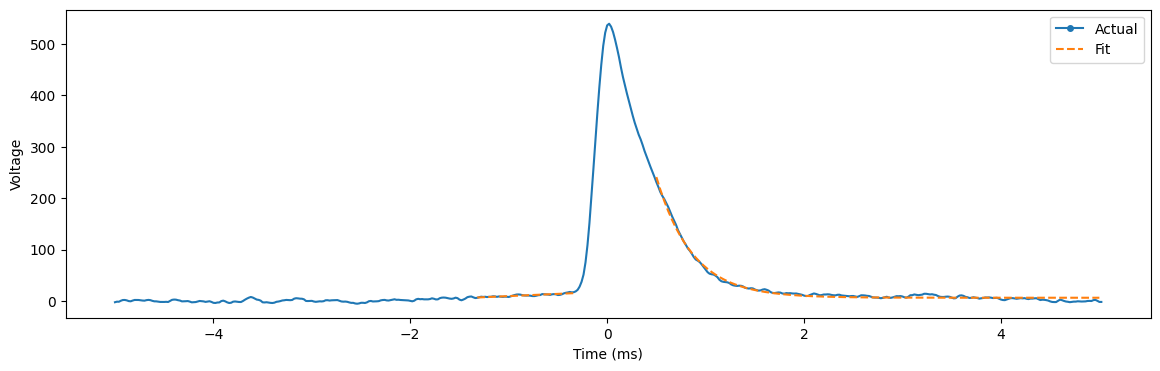

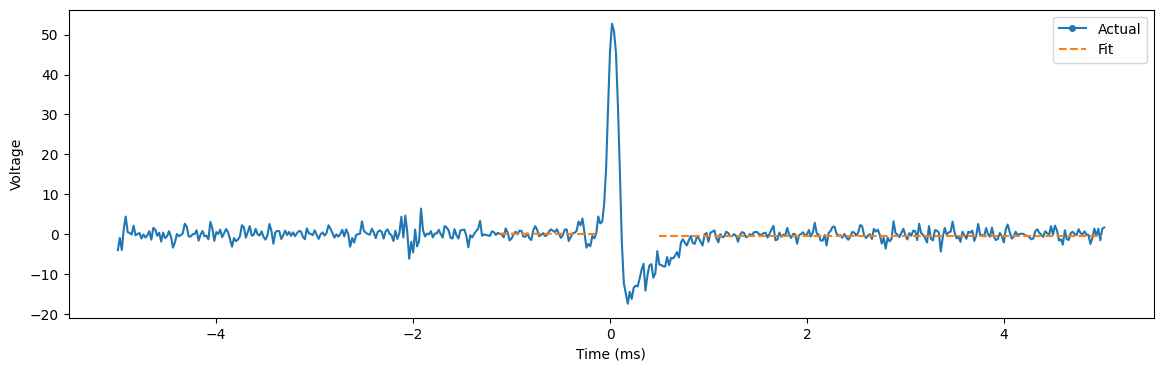

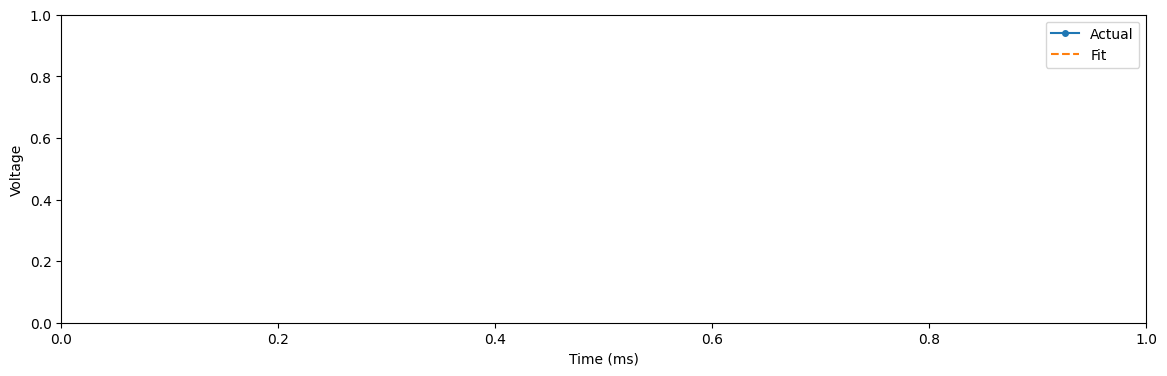

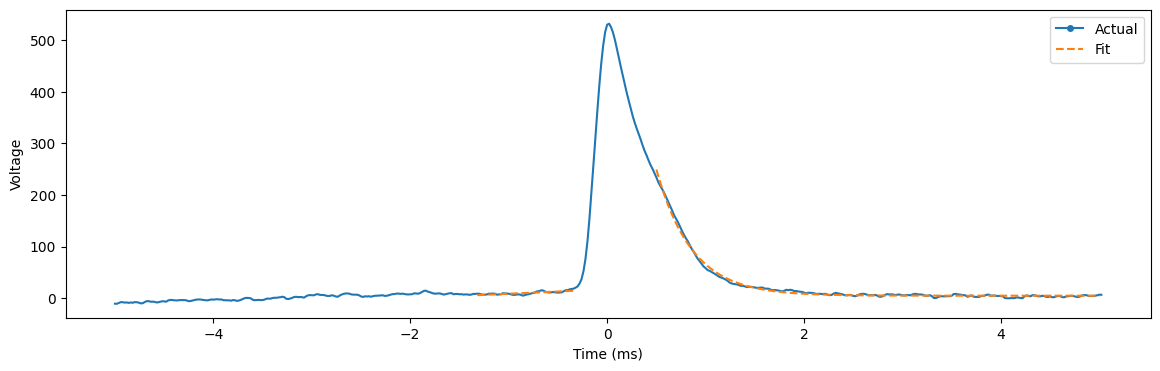

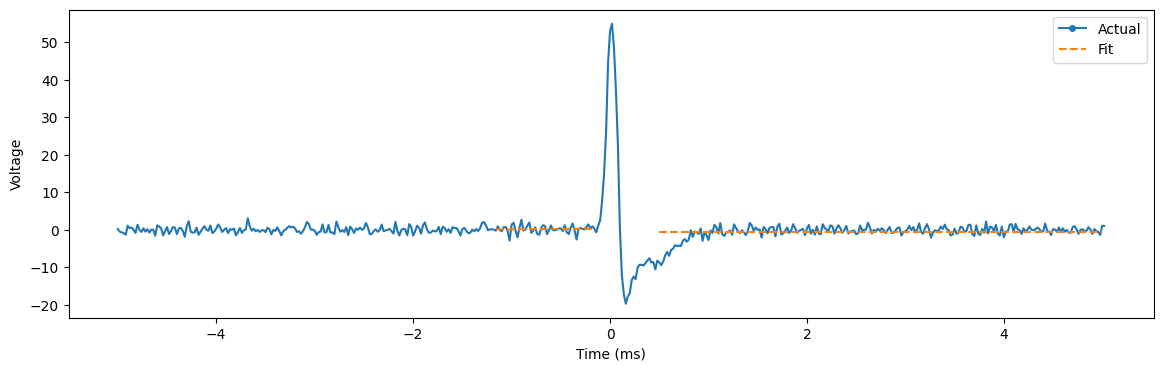

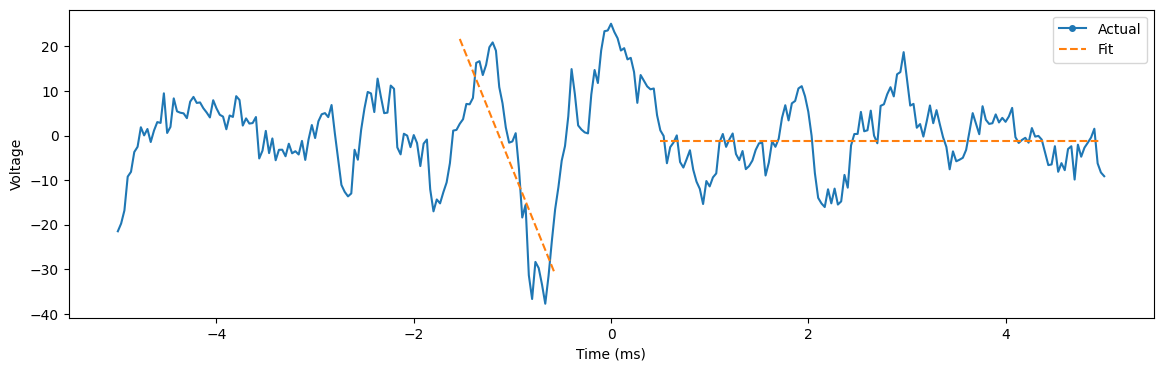

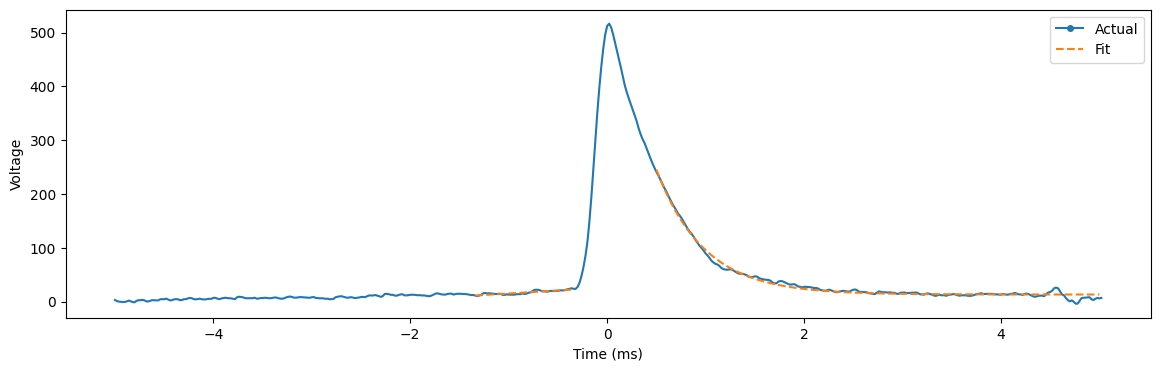

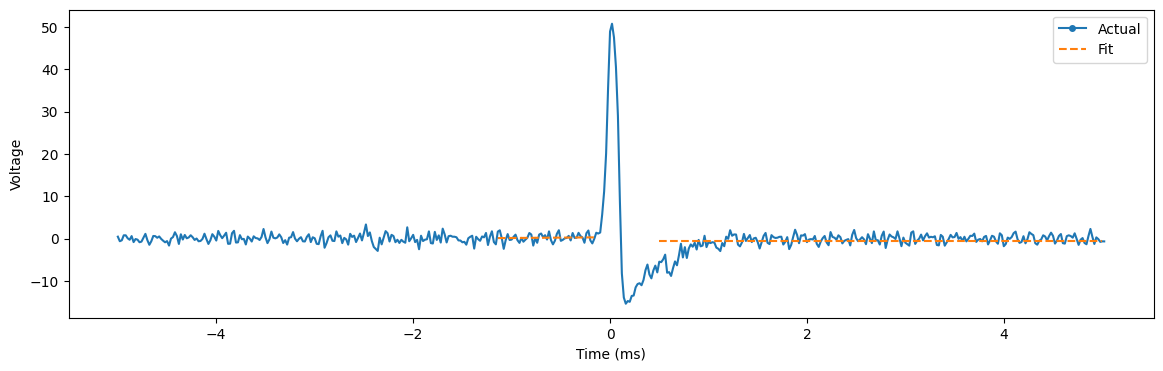

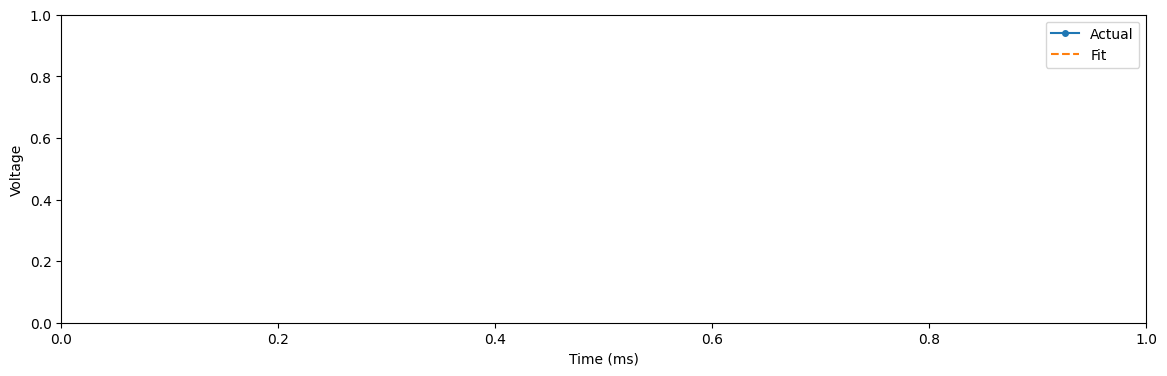

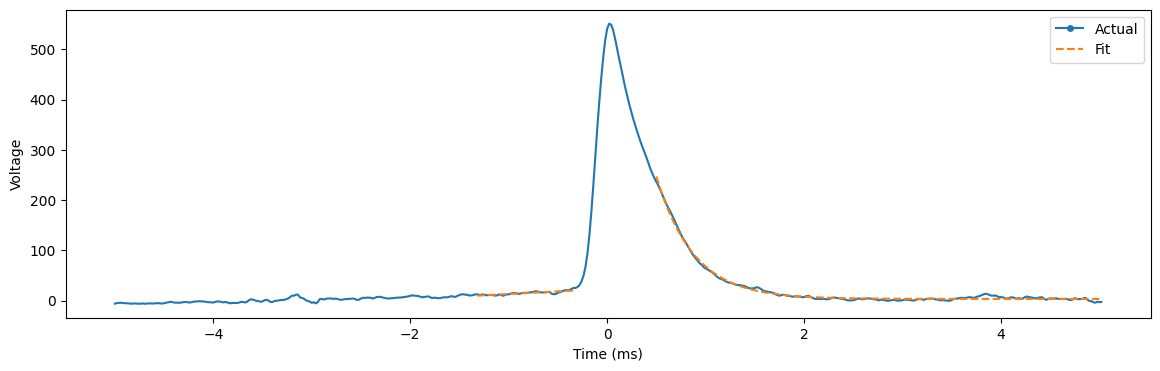

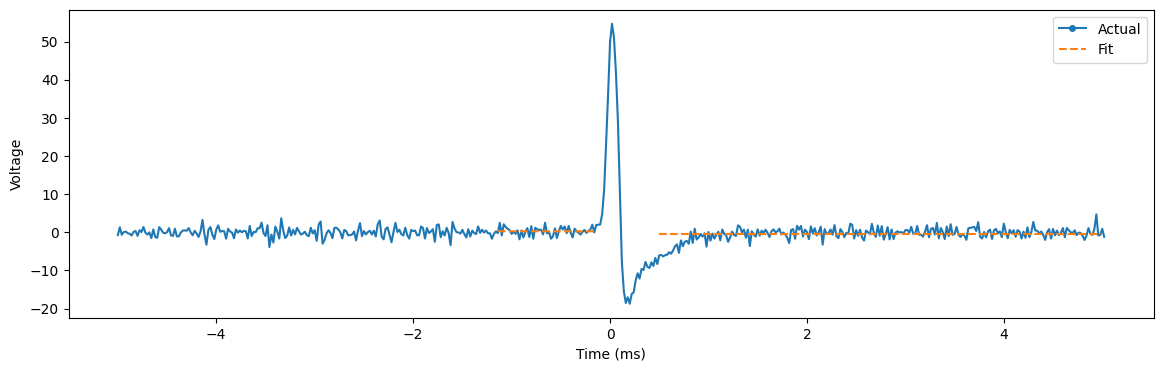

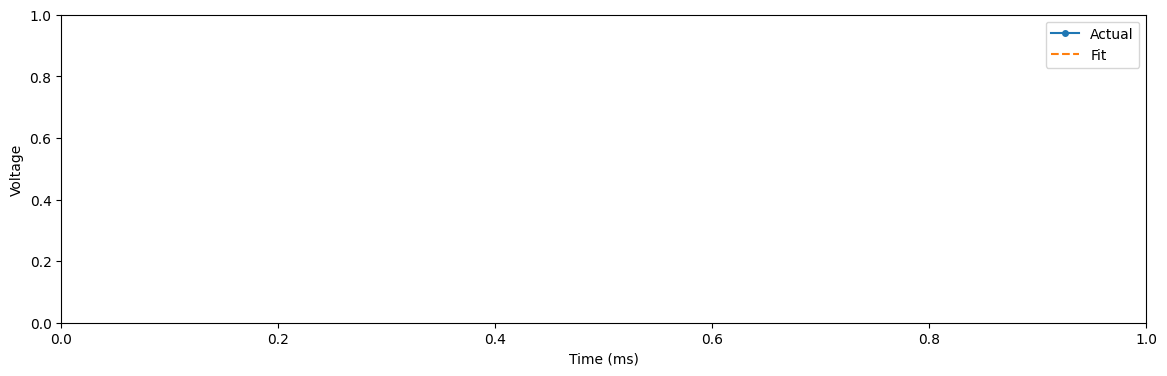

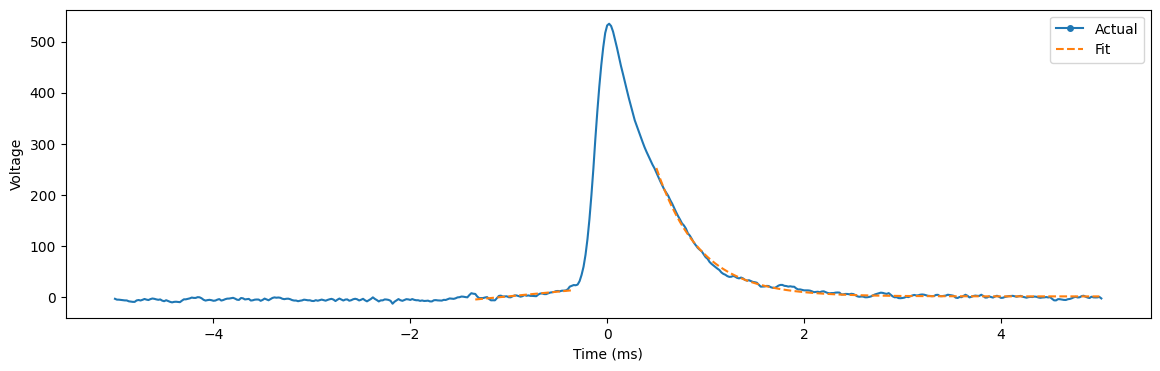

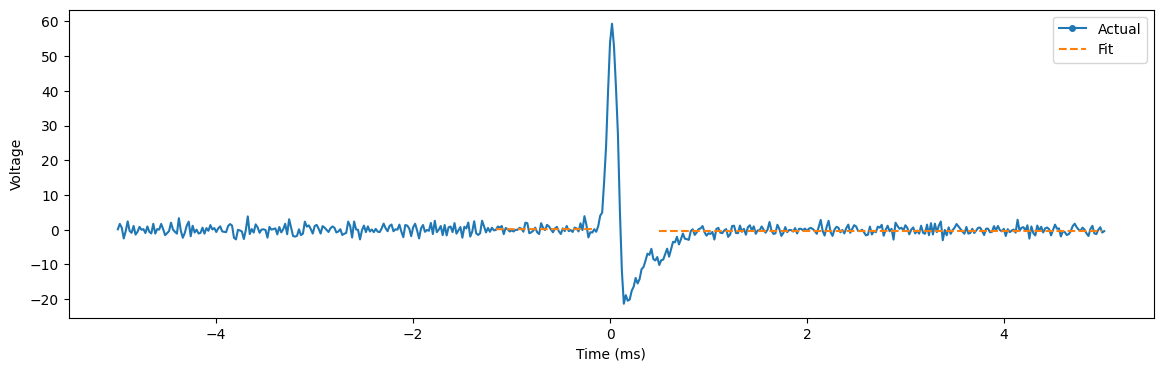

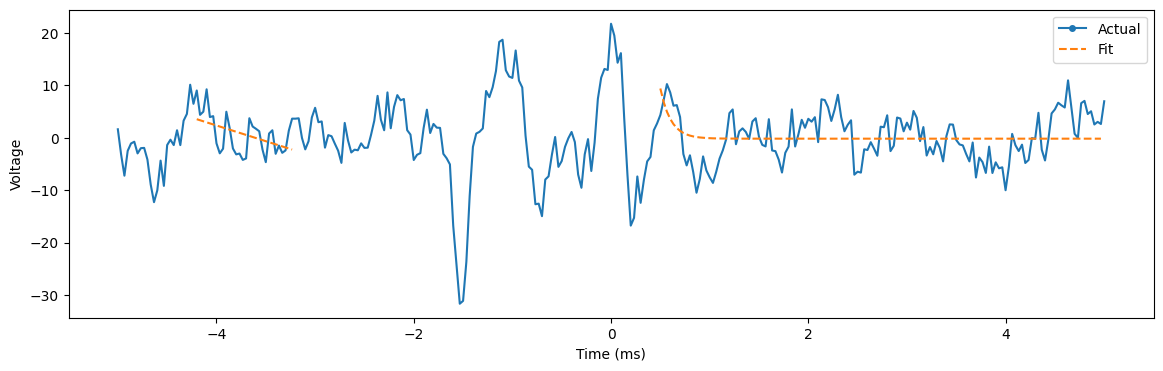

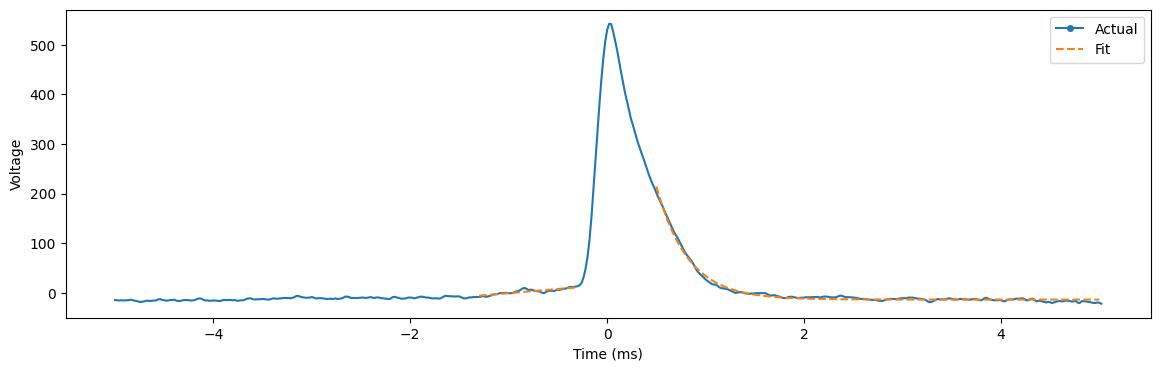

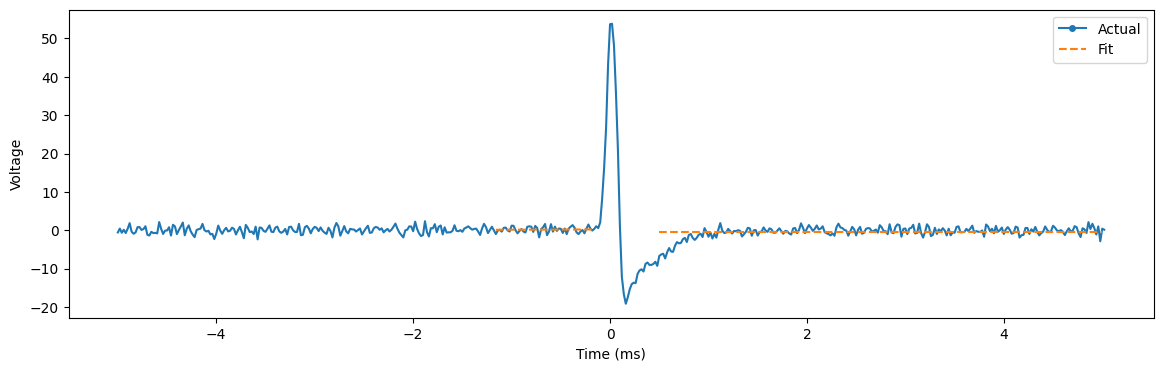

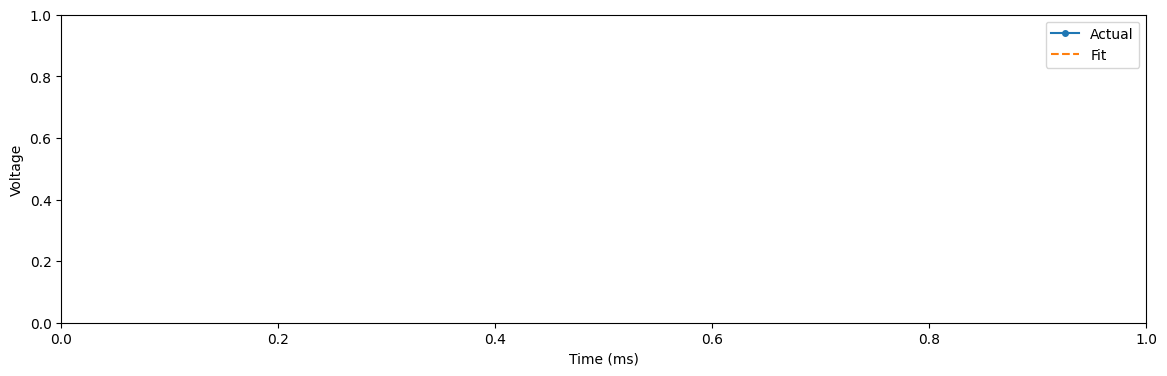

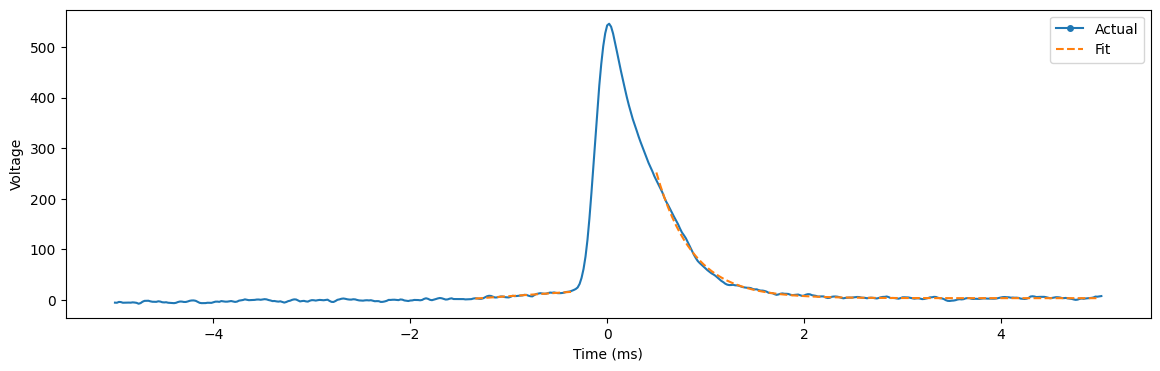

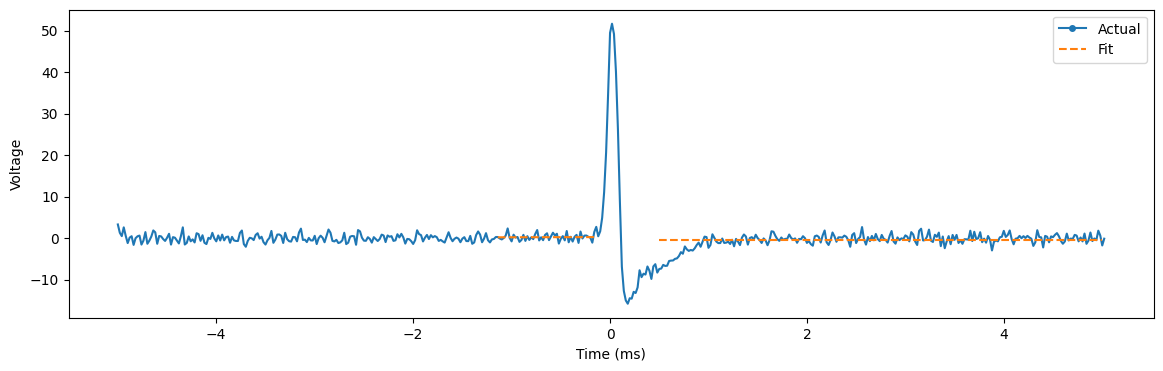

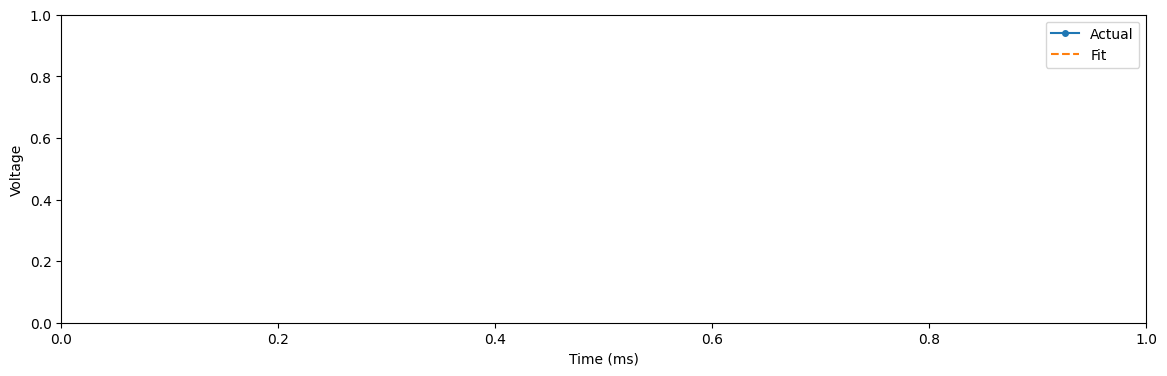

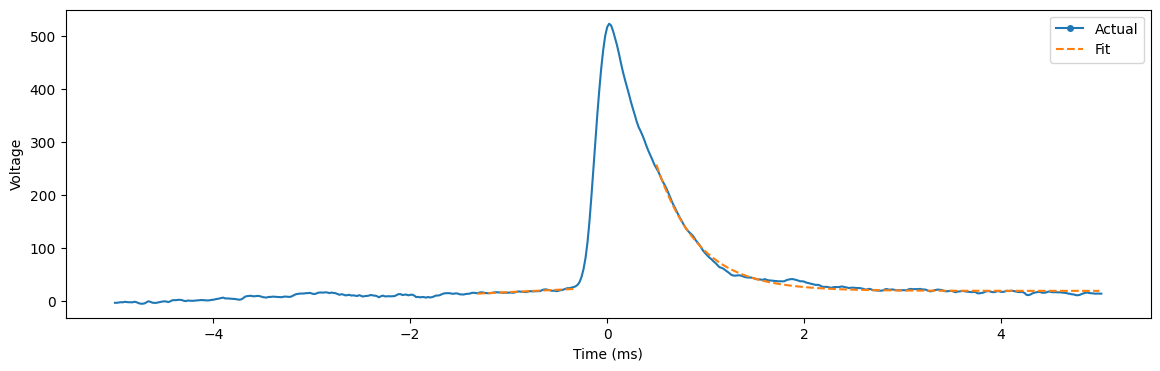

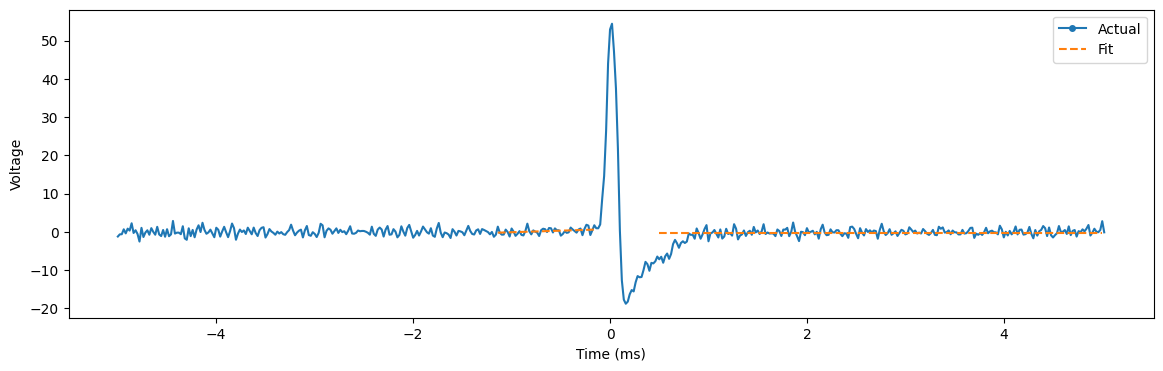

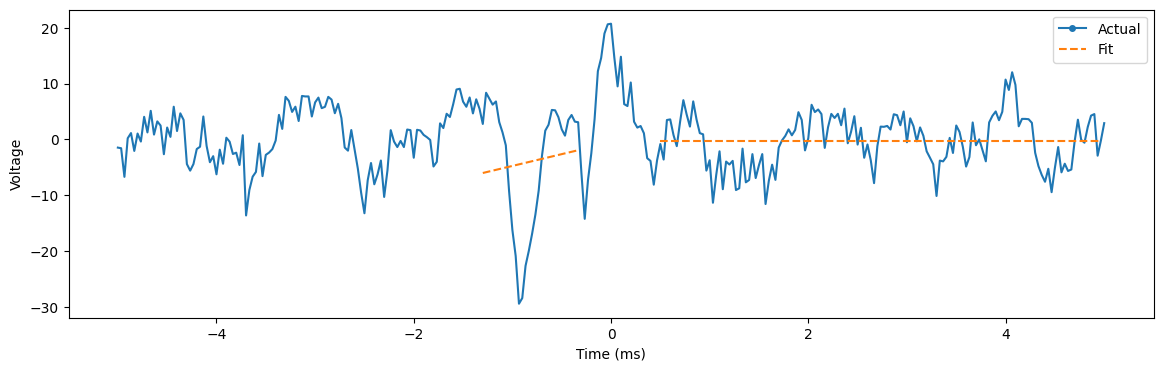

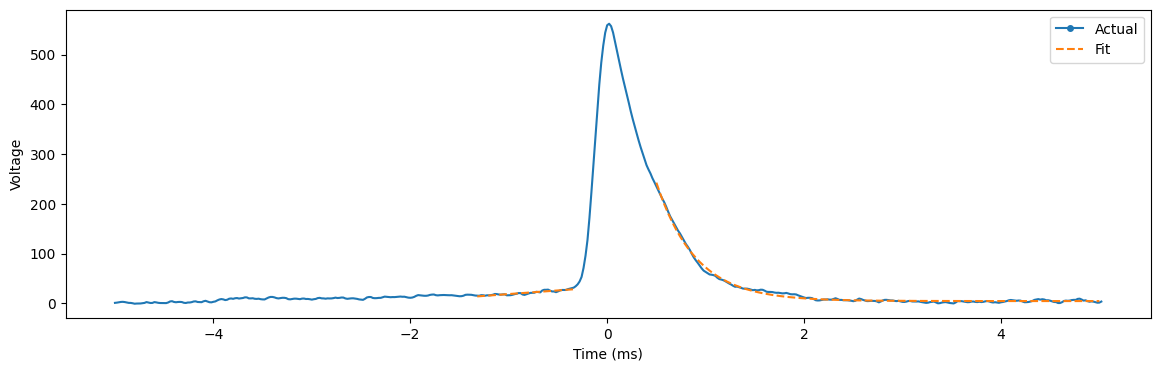

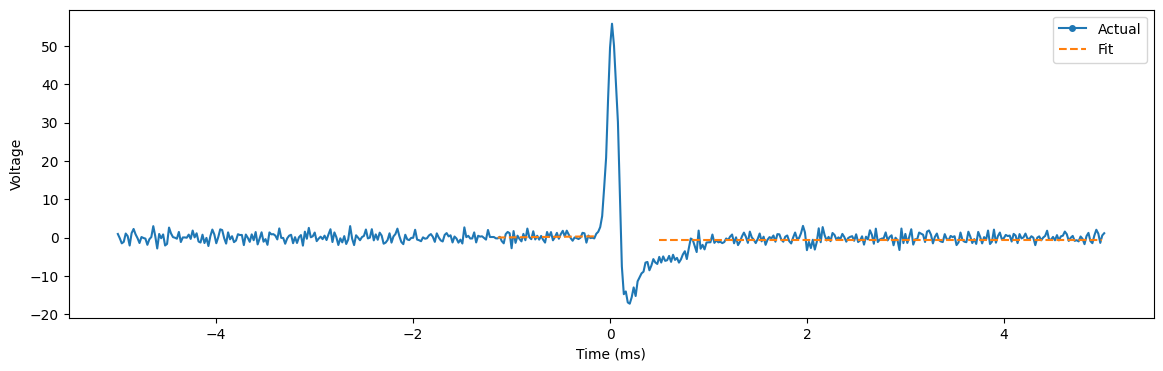

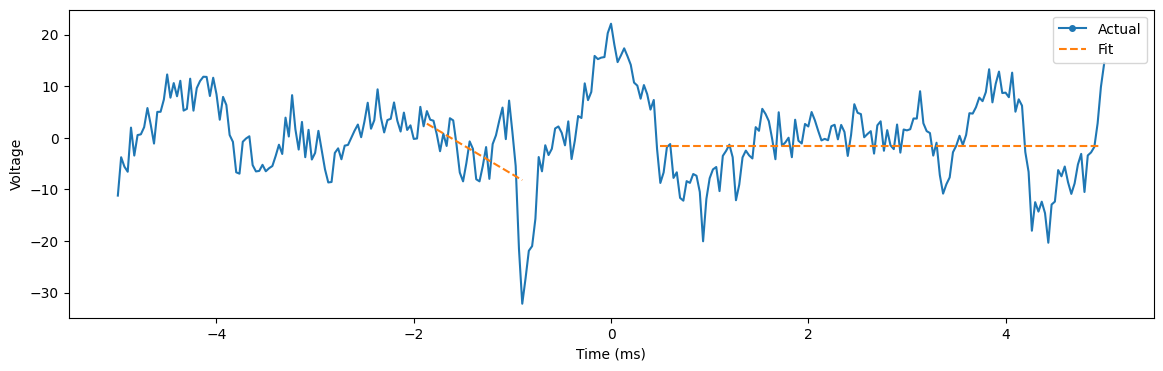

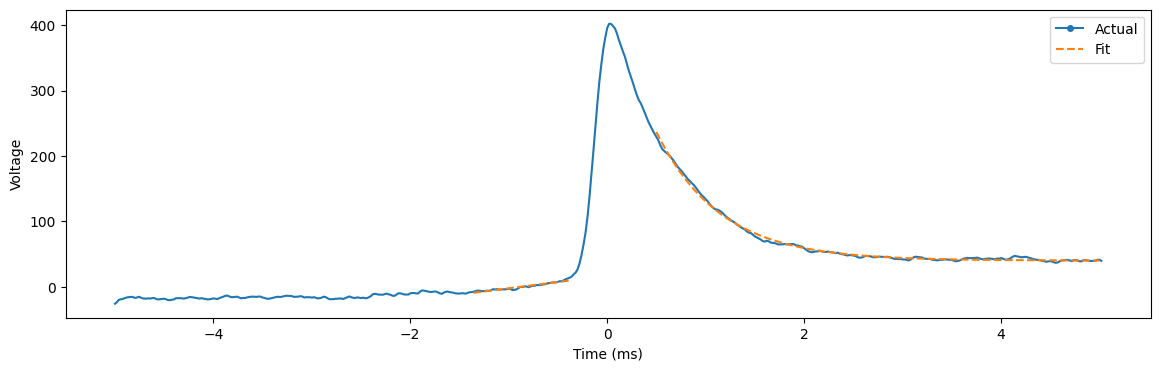

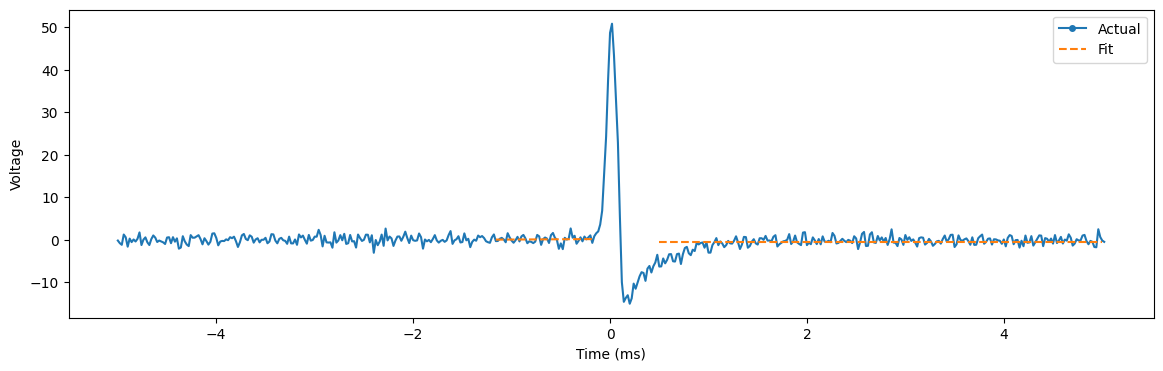

In [97]:

# Now, use the function to plot coincident spikes
#convert to indices 
coincident_iap_spikes_idx = [int(i*(patch_fs/1000)) for i in coincident_iap_spikes]

coincident_eap_spikes_idx = [int(i*(npx_fs/1000)) for i in coincident_eap_spikes]

coincident_inferred_eap_spikes_idx  = [int(i*(npx_fs/1000)) for i in coincident_iap_spikes]




# Now loop through the coincident spikes and plot them
for eap_spike_num, iap_spike_num, inferred_eap_spike_num in zip(coincident_eap_spike_num, coincident_iap_spike_num, coincident_iap_spike_num):
    
    # Plot for EAP spikes
    print(f"Plotting EAP spike at detected spike number: {eap_spike_num}")
    sp_ex.plot(eap_spike_num)
    
    # Plot for IAP spikes
    print(f"Plotting IAP spike at detected spike number: {iap_spike_num}")
    sp.plot(iap_spike_num)
    
    # Plot for Inferred EAP spikes
    print(f"Plotting Inferred EAP spike at detected spike number: {inferred_eap_spike_num}")
    sp_ex_inf.plot(inferred_eap_spike_num)

# EAP to inferred IAP